**análisis exploratorio y no supervisado de radiografías de tórax**

El código proporcionado a continuación implementa un flujo de análisis exploratorio de datos aplicado a un conjunto de radiografías de tórax clasificadas en dos grupos: imágenes normales e imágenes correspondientes a pacientes con tuberculosis. Su propósito principal es caracterizar cuantitativamente las imágenes, evaluar si existen diferencias estadísticas entre ambas clases, explorar la distribución espacial de dichas diferencias dentro de la radiografía e identificar agrupaciones naturales y posibles anomalías en el conjunto de datos.

Se emplean representaciones gráficas, pruebas de normalidad, evaluación de homogeneidad de varianzas, comparación de medias y cálculo del tamaño del efecto mediante el estadístico d de Cohen. Este análisis permite determinar no solamente si existen diferencias estadísticamente significativas entre las imágenes normales y las imágenes con tuberculosis, sino también cuantificar la magnitud de dichas diferencias.

Cada radiografía es dividida en seis regiones rectangulares: superior izquierda, superior derecha, media izquierda, media derecha, inferior izquierda e inferior derecha. Para cada región se calculan características de intensidad, variabilidad y entropía. Esta división busca estudiar la distribución espacial de la información radiográfica y establecer si determinadas zonas de la imagen presentan una mayor capacidad para diferenciar entre las dos clases.
> Añadir blockquote



In [ ]:
import os
from pathlib import Path
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import kagglehub

Esta línea utiliza la función dataset_download() de la biblioteca kagglehub para descargar el conjunto de datos Tuberculosis TB Chest X-ray Dataset desde Kaggle.

tawsifurrahman es el usuario que publicó el conjunto de datos.
tuberculosis-tb-chest-xray-dataset es el nombre del repositorio de datos.

La función descarga los archivos o utiliza la versión almacenada en caché si el conjunto ya había sido descargado previamente. La ruta local donde quedan almacenados los archivos se guarda en la variable path.

In [ ]:
path = kagglehub.dataset_download("tawsifurrahman/tuberculosis-tb-chest-xray-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tuberculosis-tb-chest-xray-dataset' dataset.
Path to dataset files: /kaggle/input/tuberculosis-tb-chest-xray-dataset


Se crea un objeto de tipo Path utilizando la biblioteca pathlib, que facilita el manejo de rutas de archivos de forma independiente del sistema operativo. A partir de la ruta base donde se descargó el conjunto de datos (path), se accede al directorio principal denominado TB_Chest_Radiography_Database, el cual contiene las diferentes categorías de imágenes.

Estas instrucciones construyen las rutas hacia las dos carpetas de interés
Normal yTuberculosis
El operador / definido por pathlib.Path concatena directorios de manera segura y legible, evitando problemas asociados con los separadores de rutas entre distintos sistemas operativos.

En esta etapa se realiza la búsqueda de todas las imágenes con extensión .png presentes en cada carpeta mediante el método glob().

glob("*.png") localiza todos los archivos cuyo nombre termina en .png.
El resultado se convierte en una lista mediante list(), almacenando la ruta completa de cada imagen.

In [ ]:
base_path = Path(path) / "TB_Chest_Radiography_Database"

normal_path = base_path / "Normal"
tb_path = base_path / "Tuberculosis"

normal_imgs = list(normal_path.glob("*.png"))
tb_imgs = list(tb_path.glob("*.png"))

print(f"Normal: {len(normal_imgs)}")
print(f"Tuberculosis: {len(tb_imgs)}")

Normal: 3500
Tuberculosis: 700


Se crea un dataframe constituido por todas las imagenes. se analizan elementos base de la conformación como las dimensiones y composición

In [ ]:
data = []

for img_path in normal_imgs:

    img = Image.open(img_path)

    data.append({
        "Nombre_Archivo": img_path.name,
        "path": str(img_path),
        "clase": "Normal",
        "Ancho": img.width,
        "Alto": img.height,
        "Modo": img.mode
    })

for img_path in tb_imgs:

    img = Image.open(img_path)

    data.append({
        "Nombre_Archivo": img_path.name,
        "path": str(img_path),
        "clase": "Tuberculosis",
        "Ancho": img.width,
        "Alto": img.height,
        "Modo": img.mode
    })

df = pd.DataFrame(data)

In [ ]:
df.head()

,Nombre_Archivo,path,clase,Ancho,Alto,Modo
0,Normal-859.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,512,512,RGB
1,Normal-158.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,512,512,RGB
2,Normal-1811.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,512,512,RGB
3,Normal-97.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,512,512,RGB
4,Normal-1088.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,512,512,RGB


Se realiza un análisis del balance de las clases

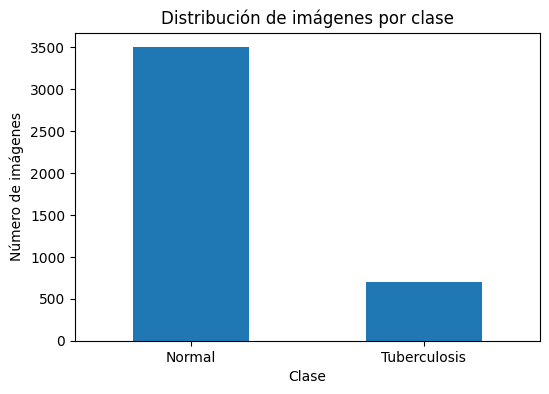

In [ ]:
plt.figure(figsize=(6,4))
df["clase"].value_counts().plot(kind="bar")
plt.title("Distribución de imágenes por clase")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=0)
plt.show()

La figura que se encuentra acontinuación buscaba observar si habia alguna imagen por fuera de las dimensiones generales

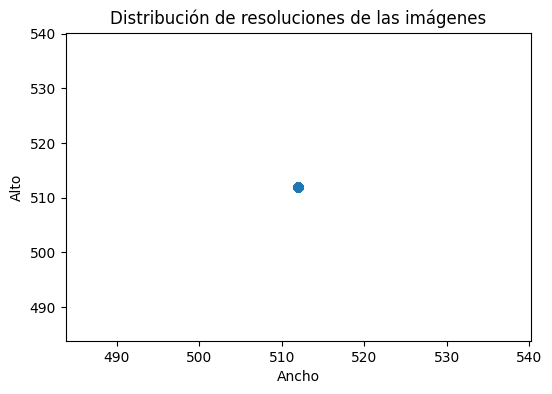

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["Ancho"], df["Alto"], alpha=0.5)
plt.title("Distribución de resoluciones de las imágenes")
plt.xlabel("Ancho")
plt.ylabel("Alto")
plt.show()

In [ ]:
import cv2
import numpy as np
from scipy.stats import entropy

Este bloque corresponde a la extracción de características globales de intensidad para cada radiografía del conjunto de datos. El objetivo es representar cada imagen mediante un conjunto reducido de descriptores estadísticos que resumen la distribución de los niveles de gris, facilitando posteriormente el análisis exploratorio y la comparación entre las clases Normal y Tuberculosis.

Se calcula el histograma de niveles de gris de la radiografía mediante la función calcHist() de OpenCV.

El histograma representa la distribución de frecuencias de intensidad de todos los píxeles de la imagen.

Los parámetros utilizados indican que:

se analiza una única imagen ([img]);
se considera el canal 0 (escala de grises);
no se utiliza ninguna máscara (None);
se generan 256 intervalos (uno por cada nivel de intensidad);
el rango analizado comprende valores entre 0 y 255.

Como resultado se obtiene un vector donde cada posición indica cuántos píxeles presentan un determinado nivel de gris.

Para cada imagen se calcula un conjunto de descriptores globales que resumen su distribución de intensidades:

clase: corresponde a la categoría diagnóstica (Normal o Tuberculosis).
mean_intensity: intensidad promedio de todos los píxeles, la cual representa el nivel global de brillo de la imagen.
std_intensity: desviación estándar de las intensidades, utilizada como indicador de variabilidad tonal.
min_intensity: valor mínimo de intensidad presente en la radiografía.
max_intensity: valor máximo de intensidad presente.
contrast: diferencia entre la intensidad máxima y mínima, empleada como una medida sencilla del rango dinámico de la imagen.
entropy: entropía de Shannon calculada sobre el histograma normalizado, que cuantifica el grado de heterogeneidad o complejidad de la distribución de intensidades. Valores elevados indican una distribución más dispersa y con mayor contenido de información, mientras que valores bajos corresponden a imágenes más homogéneas.

Para evitar problemas numéricos asociados al cálculo del logaritmo de probabilidades nulas, se suma una constante muy pequeña (1e-10) antes de calcular la entropía.

In [ ]:
features = []

for _, row in df.iterrows():

    img = cv2.imread(row["path"], cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("No se pudo leer:", row["path"])
        continue

    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    hist = hist.flatten()
    hist_prob = hist / hist.sum()

    features.append({
        "Nombre_Archivo": row["Nombre_Archivo"],
        "clase": row["clase"],
        "mean_intensity": np.mean(img),
        "std_intensity": np.std(img),
        "min_intensity": np.min(img),
        "max_intensity": np.max(img),
        "contrast": np.max(img) - np.min(img),
        "entropy": entropy(hist_prob + 1e-10)
    })

features_df = pd.DataFrame(features)

features_df.head()

,Nombre_Archivo,clase,mean_intensity,std_intensity,min_intensity,max_intensity,contrast,entropy
0,Normal-859.png,Normal,105.045048,65.569702,0,248,248,5.207325
1,Normal-158.png,Normal,98.980545,46.058954,0,216,216,4.696573
2,Normal-1811.png,Normal,160.085857,61.446556,0,254,254,5.043220
3,Normal-97.png,Normal,111.337460,65.108699,0,250,250,5.288229
4,Normal-1088.png,Normal,128.943878,72.020809,0,250,250,5.344028


In [ ]:
import seaborn as sns

Las siguientes lineas realizan análisis estadístico descriptivo asociado a las características extraidas

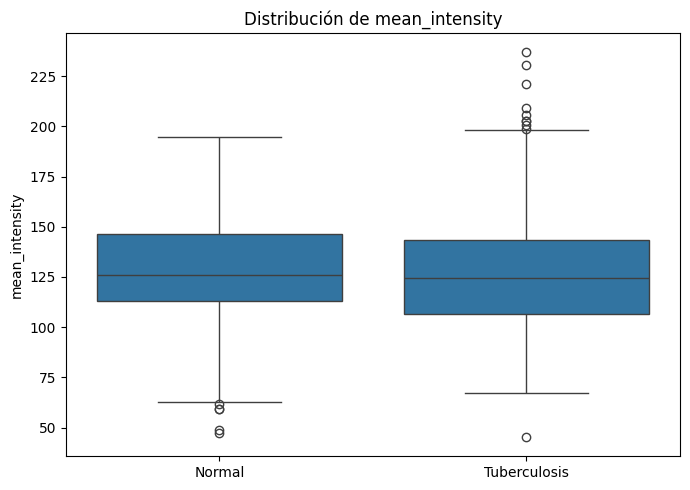

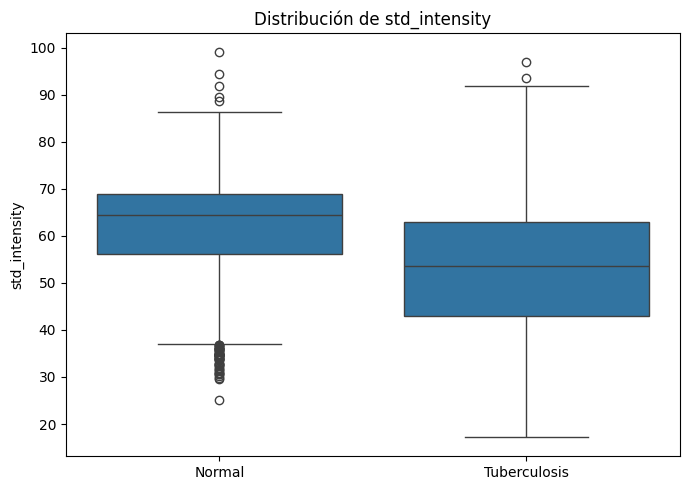

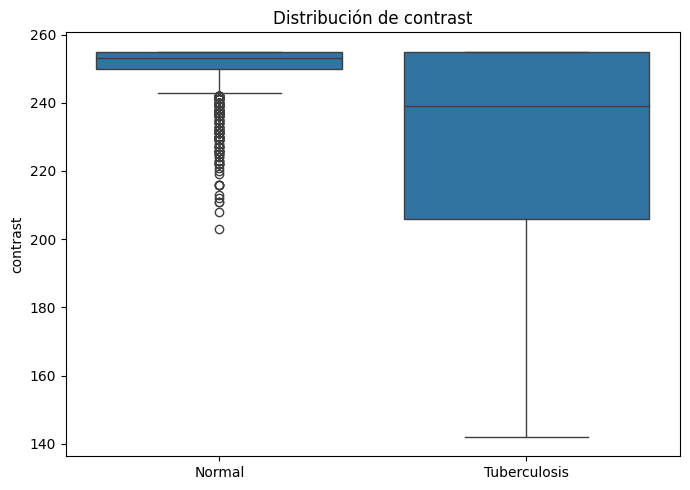

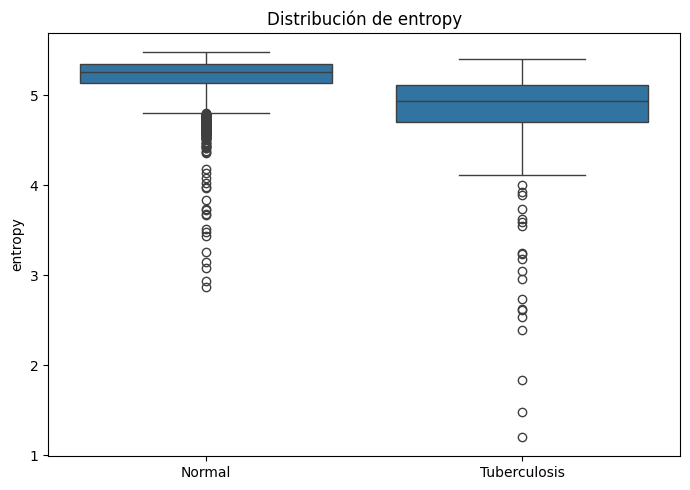

In [ ]:
variables = [
    "mean_intensity",
    "std_intensity",
    "contrast",
    "entropy"
]

for var in variables:

    plt.figure(figsize=(7,5))

    sns.boxplot(
        data=features_df,
        x="clase",
        y=var
    )

    plt.title(f"Distribución de {var}")
    plt.xlabel("")
    plt.ylabel(var)

    plt.tight_layout()
    plt.show()

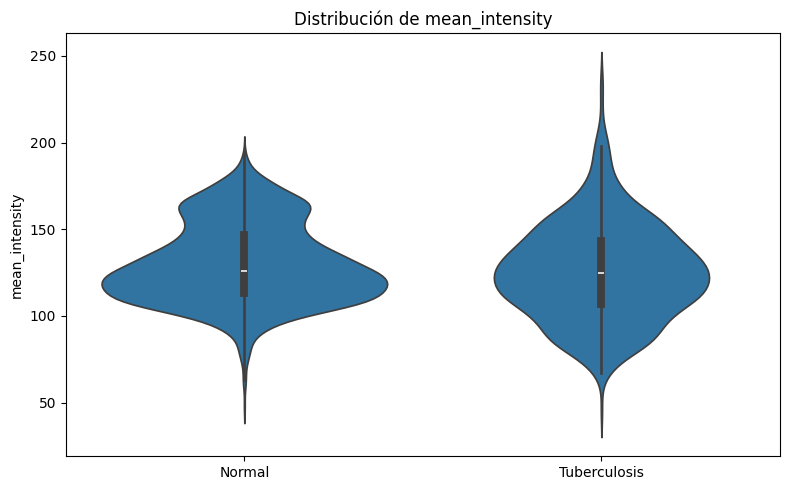

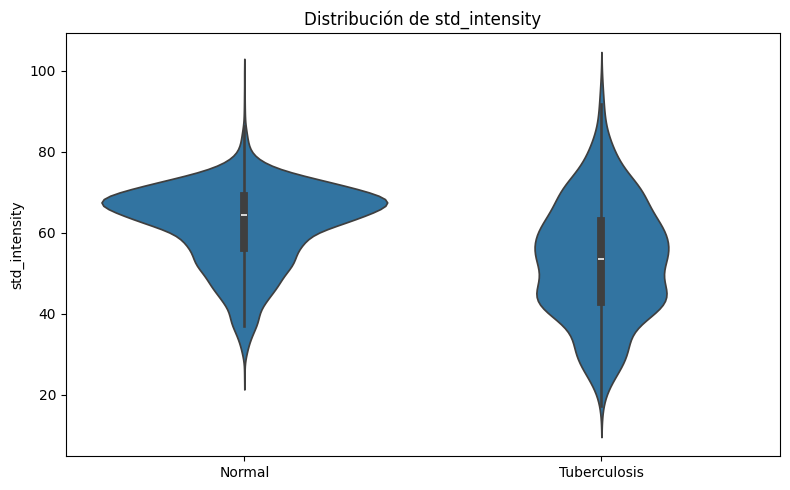

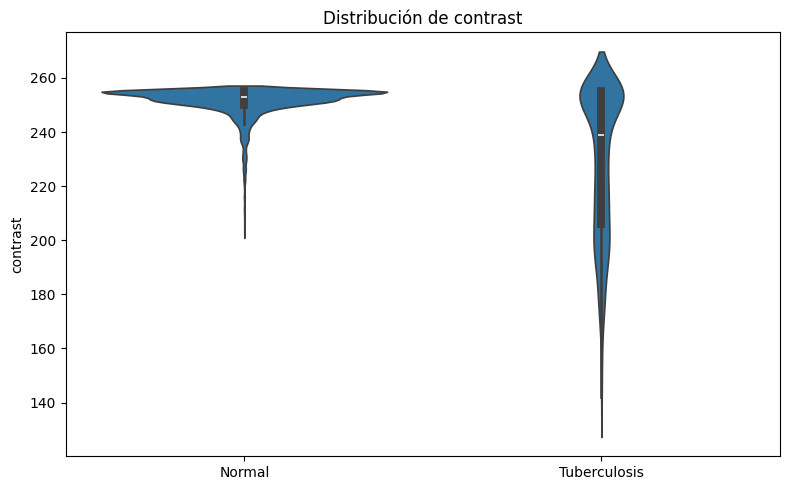

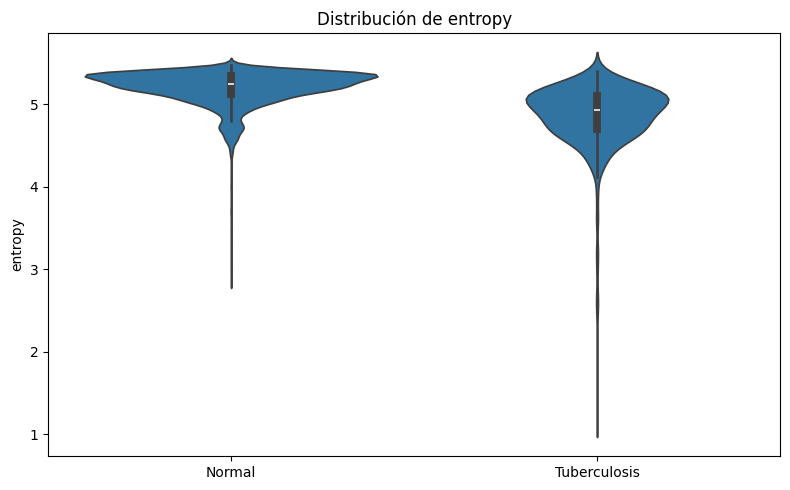

In [ ]:
variables = [
    "mean_intensity",
    "std_intensity",
    "contrast",
    "entropy"
]

for var in variables:

    plt.figure(figsize=(8,5))

    sns.violinplot(
        data=features_df,
        x="clase",
        y=var,
        inner="box"
    )

    plt.title(f"Distribución de {var}")
    plt.xlabel("")
    plt.ylabel(var)

    plt.tight_layout()
    plt.show()

In [ ]:
features_df.groupby("clase").agg(
    {
        "mean_intensity":["mean","std"],
        "std_intensity":["mean","std"],
        "contrast":["mean","std"],
        "entropy":["mean","std"]
    }
)

mean_intensity            std_intensity               contrast  \
                       mean        std          mean        std        mean   
clase                                                                         
Normal           130.123281  23.086559     62.049971   9.903073  251.306571   
Tuberculosis     125.501902  28.000795     53.059569  14.314214  229.484286   

                          entropy            
                    std      mean       std  
clase                                        
Normal         5.512283  5.199549  0.224138  
Tuberculosis  27.295365  4.851697  0.434030

In [ ]:
import scipy.stats as stats
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import ttest_ind

evalúa gráficamente el supuesto de normalidad para cada una de las variables extraídas de las radiografías, comparando de forma independiente las distribuciones correspondientes a las clases Normal y Tuberculosis. Para ello, genera diagramas de probabilidad normal (Q-Q plots), los cuales permiten determinar visualmente el grado de concordancia entre la distribución observada de cada característica y una distribución normal teórica. Esta evaluación constituye un paso previo al análisis estadístico inferencial, ya que permite seleccionar posteriormente las pruebas de hipótesis más apropiadas según se cumpla o no el supuesto de normalidad.

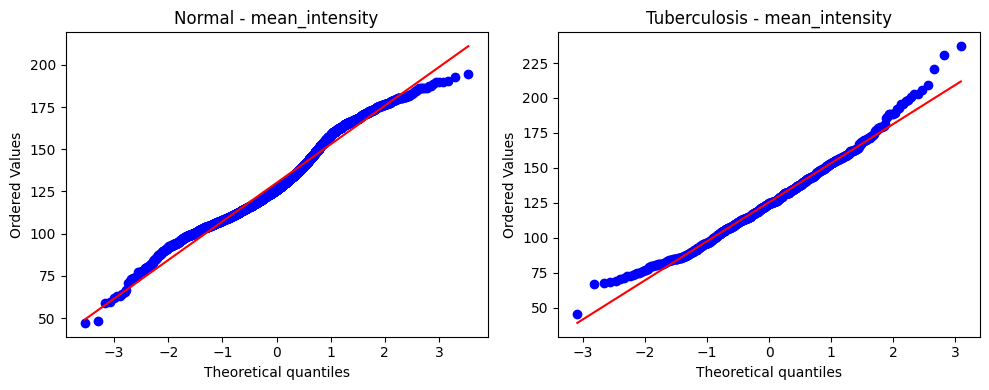

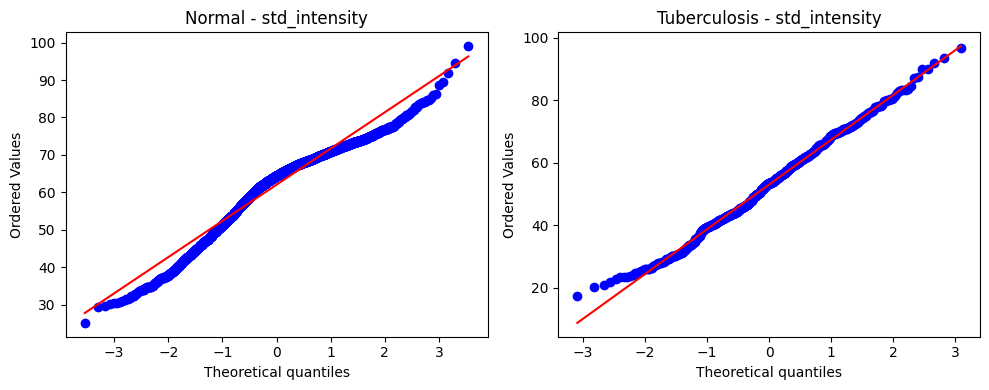

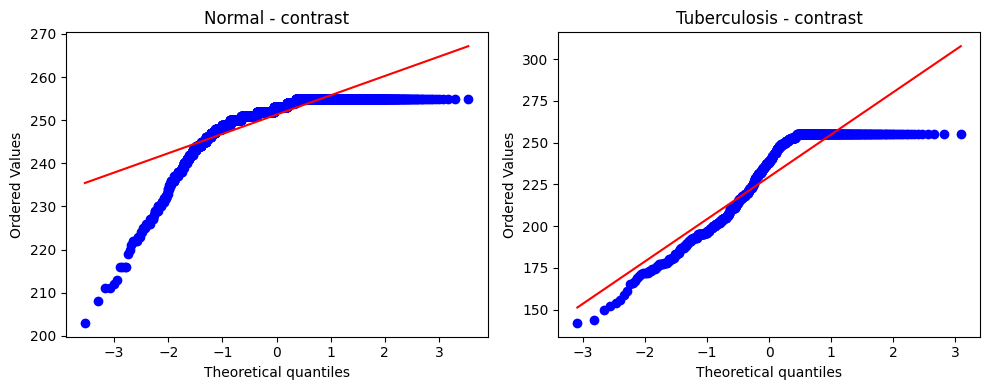

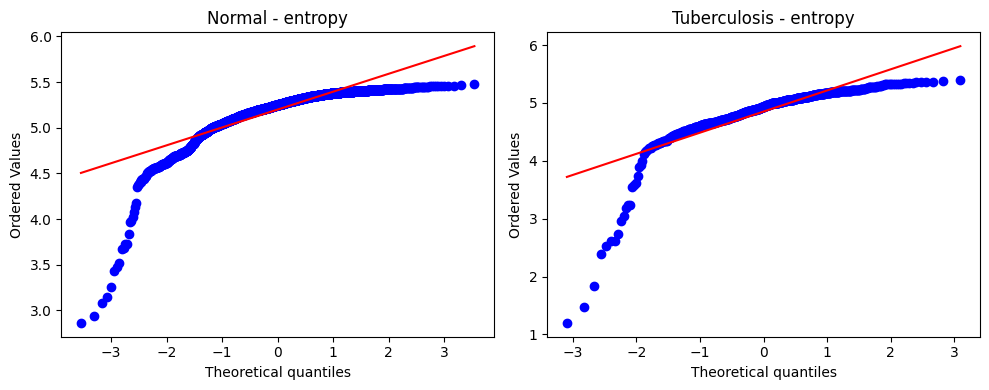

In [ ]:
for var in variables:

    fig, axes = plt.subplots(1,2, figsize=(10,4))

    normal = features_df[
        features_df["clase"]=="Normal"
    ][var]

    tb = features_df[
        features_df["clase"]=="Tuberculosis"
    ][var]

    stats.probplot(normal, dist="norm", plot=axes[0])
    axes[0].set_title(f"Normal - {var}")

    stats.probplot(tb, dist="norm", plot=axes[1])
    axes[1].set_title(f"Tuberculosis - {var}")

    plt.tight_layout()
    plt.show()

Se realiza una evaluación estadística del supuesto de normalidad para cada una de las características extraídas de las radiografías, analizando por separado las clases Normal y Tuberculosis. Para ello, aplica la prueba de Shapiro-Wilk sobre una muestra aleatoria de hasta 500 observaciones por grupo, limitando el tamaño de la muestra debido a las restricciones y sensibilidad de esta prueba en conjuntos de datos muy grandes. Como resultado, se obtiene el valor p para cada clase y variable, el cual permite determinar si existe evidencia suficiente para rechazar la hipótesis de que los datos provienen de una distribución normal.

In [ ]:
for var in variables:

    normal = features_df[
        features_df["clase"]=="Normal"
    ][var]

    tb = features_df[
        features_df["clase"]=="Tuberculosis"
    ][var]

    normal_sample = normal.sample(
        min(500, len(normal)),
        random_state=42
    )

    tb_sample = tb.sample(
        min(500, len(tb)),
        random_state=42
    )

    p_normal = shapiro(normal_sample)[1]
    p_tb = shapiro(tb_sample)[1]

    print(f"\n{var}")
    print(f"Normal p = {p_normal:.5f}")
    print(f"Tuberculosis p = {p_tb:.5f}")


mean_intensity
Normal p = 0.00000
Tuberculosis p = 0.00012

std_intensity
Normal p = 0.00000
Tuberculosis p = 0.05863

contrast
Normal p = 0.00000
Tuberculosis p = 0.00000

entropy
Normal p = 0.00000
Tuberculosis p = 0.00000


Se valúa el supuesto de homogeneidad de varianzas entre las clases Normal y Tuberculosis para cada una de las características extraídas. Para ello, aplica la prueba de Levene, la cual determina si la variabilidad de una característica es estadísticamente equivalente entre ambos grupos. El valor p obtenido para cada variable permite establecer si se cumple el supuesto de igualdad de varianzas.

In [ ]:
for var in variables:

    normal = features_df[
        features_df["clase"]=="Normal"
    ][var]

    tb = features_df[
        features_df["clase"]=="Tuberculosis"
    ][var]

    stat, p = levene(normal, tb)

    print(f"{var}: p = {p:.5f}")

mean_intensity: p = 0.00000
std_intensity: p = 0.00000
contrast: p = 0.00000
entropy: p = 0.00000


Se compara estadísticamente las medias de cada una de las características extraídas entre las clases Normal y Tuberculosis mediante la prueba t de Welch. A diferencia de la prueba t de Student convencional, esta variante no asume igualdad de varianzas entre los grupos, por lo que resulta adecuada cuando dicho supuesto no se cumple o existe incertidumbre sobre él. Para cada variable se calcula el valor p, el cual permite determinar si las diferencias observadas entre las medias de ambas clases son estadísticamente significativas.

In [ ]:
for var in variables:

    normal = features_df[
        features_df["clase"]=="Normal"
    ][var]

    tb = features_df[
        features_df["clase"]=="Tuberculosis"
    ][var]

    stat, p = ttest_ind(
        normal,
        tb,
        equal_var=False
    )

    print(f"{var}: p = {p:.10f}")

mean_intensity: p = 0.0000456294
std_intensity: p = 0.0000000000
contrast: p = 0.0000000000
entropy: p = 0.0000000000


Este bloque calcula el tamaño del efecto para cada una de las características extraídas utilizando el estadístico d de Cohen. Inicialmente se define una función que estima la diferencia estandarizada entre las medias de dos grupos independientes a partir de la desviación estándar combinada (pooled standard deviation). Posteriormente, la función es aplicada a cada variable para comparar las clases Normal y Tuberculosis, obteniendo un valor de d que cuantifica la magnitud de la diferencia observada.

El tamaño del efecto (d de Cohen) cuantifica la magnitud de la diferencia entre dos grupos de forma estandarizada, expresándola en unidades de desviación estándar. A diferencia del valor p, que indica si una diferencia es estadísticamente significativa, el tamaño del efecto permite evaluar su importancia práctica. En términos generales, se consideran valores de ∣d∣≈0.2 como un efecto pequeño, ∣d∣≈0.5 como moderado y ∣d∣≥0.8 como un efecto grande. Cuanto mayor sea el valor absoluto de d, mayor será la capacidad de esa característica para diferenciar entre los grupos analizados. El signo únicamente indica la dirección de la diferencia (qué grupo presenta la media más alta), mientras que la magnitud del efecto se interpreta a partir de su valor absoluto.

In [ ]:
def cohens_d(x, y):

    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        (
            (nx - 1) * np.var(x, ddof=1)
            +
            (ny - 1) * np.var(y, ddof=1)
        )
        /
        (nx + ny - 2)
    )

    return (np.mean(x) - np.mean(y)) / pooled_std

In [ ]:
for var in variables:

    normal = features_df[
        features_df["clase"]=="Normal"
    ][var]

    tb = features_df[
        features_df["clase"]=="Tuberculosis"
    ][var]

    d = cohens_d(normal, tb)

    print(f"{var}: Cohen's d = {d:.3f}")

mean_intensity: Cohen's d = 0.193
std_intensity: Cohen's d = 0.835
contrast: Cohen's d = 1.785
entropy: Cohen's d = 1.285


In [ ]:
results = []

for var in variables:

    normal = features_df[
        features_df["clase"]=="Normal"
    ][var]

    tb = features_df[
        features_df["clase"]=="Tuberculosis"
    ][var]

    p = ttest_ind(
        normal,
        tb,
        equal_var=False
    )[1]

    d = cohens_d(normal, tb)

    results.append({
        "Variable": var,
        "Normal_Mean": normal.mean(),
        "TB_Mean": tb.mean(),
        "p_value": p,
        "Cohens_d": d
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,Variable,Normal_Mean,TB_Mean,p_value,Cohens_d
0,mean_intensity,130.1233,125.5019,0.0,0.1928
1,std_intensity,62.0500,53.0596,0.0,0.8352
2,contrast,251.3066,229.4843,0.0,1.7855
3,entropy,5.1995,4.8517,0.0,1.2853


En la siguiente sección se espera poder seccionar las imagenes de radiografia para poder observar en que partes puede existir mayor capacidad discriminativa de la enfermedad. Este primer bloque divide la imagen de radiografia en 6 secciones

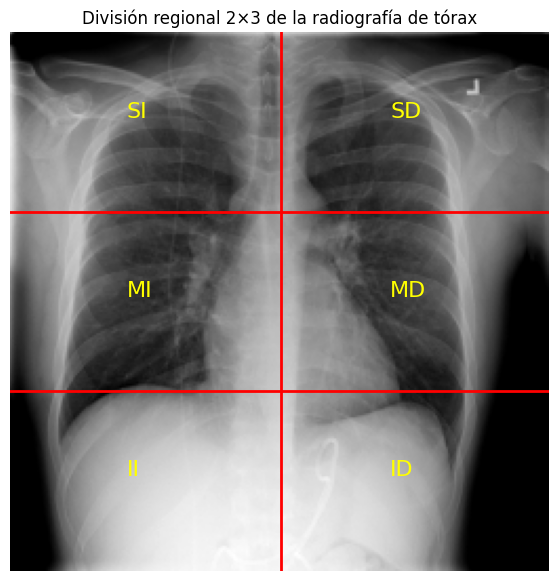

In [ ]:
img = cv2.imread(df["path"].iloc[0], cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256, 256))

h, w = img.shape

x_mid = w // 2
y1 = h // 3
y2 = 2 * h // 3

plt.figure(figsize=(7,7))
plt.imshow(img, cmap="gray")

plt.axvline(x=x_mid, color="red", linewidth=2)
plt.axhline(y=y1, color="red", linewidth=2)
plt.axhline(y=y2, color="red", linewidth=2)

plt.text(55, 40, "SI", color="yellow", fontsize=16)
plt.text(180, 40, "SD", color="yellow", fontsize=16)
plt.text(55, 125, "MI", color="yellow", fontsize=16)
plt.text(180, 125, "MD", color="yellow", fontsize=16)
plt.text(55, 210, "II", color="yellow", fontsize=16)
plt.text(180, 210, "ID", color="yellow", fontsize=16)

plt.title("División regional 2×3 de la radiografía de tórax")
plt.axis("off")
plt.show()

In [ ]:
def dividir_en_regiones(img):
    h, w = img.shape

    x_mid = w // 2
    y1 = h // 3
    y2 = 2 * h // 3

    regiones = {
        "SI": img[0:y1, 0:x_mid],
        "SD": img[0:y1, x_mid:w],
        "MI": img[y1:y2, 0:x_mid],
        "MD": img[y1:y2, x_mid:w],
        "II": img[y2:h, 0:x_mid],
        "ID": img[y2:h, x_mid:w]
    }

    return regiones

Se realiza la extracción de características regionales de cada radiografía con el propósito de analizar la distribución espacial de la información contenida en la imagen. Para ello, cada radiografía es cargada en escala de grises y redimensionada a un tamaño uniforme de 256 × 256 píxeles, garantizando que todas las imágenes posean la misma resolución antes del análisis. Posteriormente, la imagen se divide en un conjunto de regiones predefinidas mediante la función dividir_en_regiones(). Sobre cada región se calculan tres descriptores estadísticos: la intensidad media, que representa el nivel promedio de brillo; la desviación estándar, que cuantifica la variabilidad de las intensidades; y la entropía, que mide la complejidad de la distribución de niveles de gris. Finalmente, las características regionales de cada radiografía se almacenan en un DataFrame, donde cada fila corresponde a una imagen y cada columna representa un descriptor específico de una región determinada, constituyendo la base para los análisis posteriores de reducción de dimensionalidad, agrupamiento y comparación entre clases.

In [ ]:
regional_features = []

for _, row in df.iterrows():

    img = cv2.imread(
        row["path"],
        cv2.IMREAD_GRAYSCALE
    )

    img = cv2.resize(img, (256,256))

    regiones = dividir_en_regiones(img)

    registro = {
        "Nombre_Archivo": row["Nombre_Archivo"],
        "clase": row["clase"]
    }

    for nombre_region, region in regiones.items():

        hist = cv2.calcHist(
            [region],
            [0],
            None,
            [256],
            [0,256]
        )

        hist = hist.flatten()
        hist = hist / hist.sum()

        registro[f"{nombre_region}_mean"] = np.mean(region)
        registro[f"{nombre_region}_std"] = np.std(region)
        registro[f"{nombre_region}_entropy"] = entropy(hist + 1e-10)

    regional_features.append(registro)

regional_df = pd.DataFrame(regional_features)

regional_df.head()

,Nombre_Archivo,clase,SI_mean,SI_std,SI_entropy,SD_mean,SD_std,SD_entropy,MI_mean,MI_std,MI_entropy,MD_mean,MD_std,MD_entropy,II_mean,II_std,II_entropy,ID_mean,ID_std,ID_entropy
0,Normal-859.png,Normal,95.624632,46.973531,5.096575,84.558456,40.805147,4.969596,96.259191,47.999651,5.104322,85.436581,51.273506,4.921625,153.183957,77.139011,4.963658,115.212118,86.803641,4.488998
1,Normal-158.png,Normal,90.407629,42.056373,4.568090,85.861581,43.641310,4.562295,111.423897,32.040506,4.615506,100.022610,38.046296,4.587980,109.732649,53.407716,4.286876,97.115280,56.197432,4.281219
2,Normal-1811.png,Normal,142.015074,69.620219,4.877868,150.404504,52.438641,4.922106,151.211581,55.681317,4.724818,175.946324,33.681604,4.643379,160.347929,82.958252,4.651614,181.101017,51.177062,4.902532
3,Normal-97.png,Normal,97.894669,59.810197,4.953109,114.605423,55.887496,5.171929,93.238695,48.140537,5.040965,116.065441,55.142654,5.123088,103.210938,80.592912,4.952549,143.436682,71.762702,5.276061
4,Normal-1088.png,Normal,77.330147,47.687031,5.002809,74.089062,48.841775,4.941105,149.940441,48.453375,5.024891,127.974081,51.186735,5.135364,198.487373,47.283300,4.460717,145.538790,89.051038,4.641360


In [ ]:
print(regional_df.shape)

(4200, 20)


En los dos bloques siguientes se realiza el analisis estadistico basico pero ahora no para las imagenes completas sino para cada subsección

In [ ]:
regional_df.groupby("clase").mean(numeric_only=True).T

clase,Normal,Tuberculosis
SI_mean,102.884414,121.653899
SI_std,52.193478,44.278992
SI_entropy,4.886683,4.731702
SD_mean,104.601264,120.658770
SD_std,51.836771,44.151576
SD_entropy,4.913662,4.662364
MI_mean,123.884343,119.926073
MI_std,46.614880,44.538440
MI_entropy,4.956861,4.701069
MD_mean,130.618712,124.843517


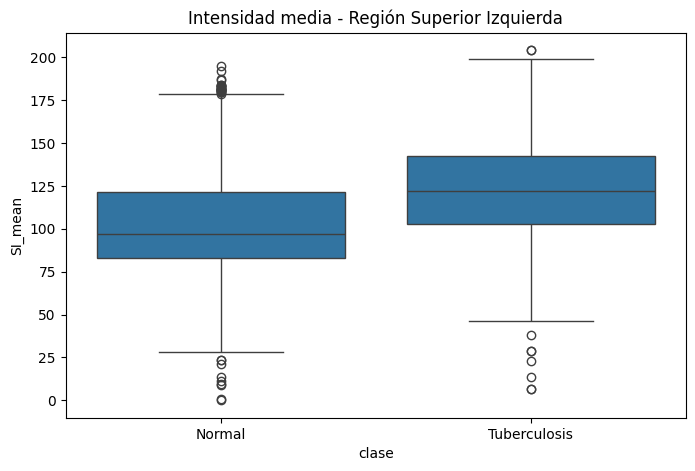

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=regional_df,
    x="clase",
    y="SI_mean"
)

plt.title("Intensidad media - Región Superior Izquierda")
plt.show()

In [ ]:
resultados_d = []

variables = [
    c for c in regional_df.columns
    if c not in ["Nombre_Archivo", "clase"]
]

for var in variables:

    normal = regional_df[
        regional_df["clase"]=="Normal"
    ][var]

    tb = regional_df[
        regional_df["clase"]=="Tuberculosis"
    ][var]

    d = cohens_d(normal, tb)

    resultados_d.append({
        "Variable": var,
        "Cohens_d": d,
        "Abs_d": abs(d)
    })

cohen_df = pd.DataFrame(resultados_d)

cohen_df = cohen_df.sort_values(
    "Abs_d",
    ascending=False
)

cohen_df.head(20)

,Variable,Cohens_d,Abs_d
11,MD_entropy,1.127402,1.127402
8,MI_entropy,0.981532,0.981532
12,II_mean,0.870951,0.870951
17,ID_entropy,0.864682,0.864682
1,SI_std,0.834191,0.834191
4,SD_std,0.783564,0.783564
15,ID_mean,0.728549,0.728549
14,II_entropy,0.643682,0.643682
0,SI_mean,-0.643121,0.643121
5,SD_entropy,0.638312,0.638312


In [ ]:
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib.colors as colors

El siguiente bloque toma los valores maximos de diferencia en terminos de la magnitud del efecto anañalizado con cohen para realizar un grafico que permita identificar en que parte se pueden observar las principales diferencias entre las clases

/tmp/ipykernel_9269/3519554648.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlOrRd")


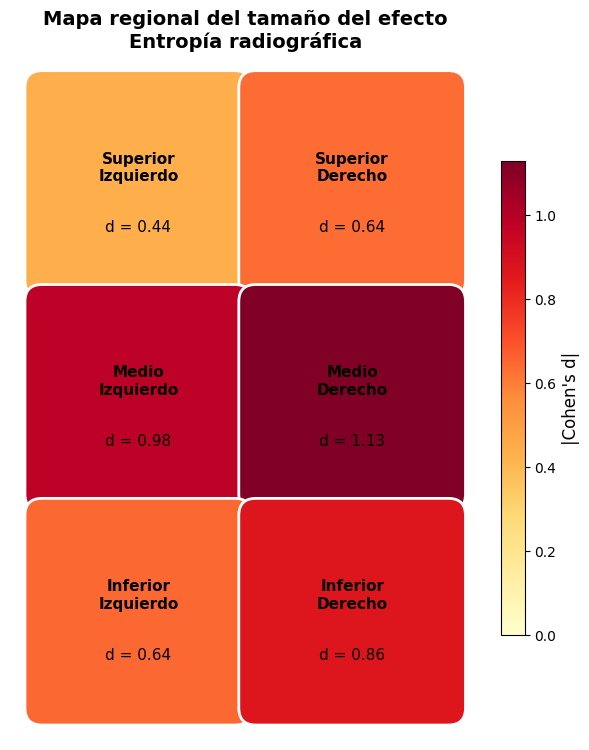

In [ ]:
valores = {
    "SI": 0.438424,
    "SD": 0.638312,
    "MI": 0.981532,
    "MD": 1.127402,
    "II": 0.643682,
    "ID": 0.864682
}

# Normalización de colores
vmin = 0
vmax = max(valores.values())
norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.get_cmap("YlOrRd")

fig, ax = plt.subplots(figsize=(6, 8))

regiones = {
    "SI": (0, 2, 1, 1),
    "SD": (1, 2, 1, 1),
    "MI": (0, 1, 1, 1),
    "MD": (1, 1, 1, 1),
    "II": (0, 0, 1, 1),
    "ID": (1, 0, 1, 1)
}

nombres = {
    "SI": "Superior\nIzquierdo",
    "SD": "Superior\nDerecho",
    "MI": "Medio\nIzquierdo",
    "MD": "Medio\nDerecho",
    "II": "Inferior\nIzquierdo",
    "ID": "Inferior\nDerecho"
}

for region, (x, y, w, h) in regiones.items():
    valor = valores[region]
    color = cmap(norm(valor))

    rect = patches.FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=2,
        edgecolor="white",
        facecolor=color
    )

    ax.add_patch(rect)

    ax.text(
        x + w/2,
        y + h/2 + 0.08,
        nombres[region],
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    ax.text(
        x + w/2,
        y + h/2 - 0.20,
        f"d = {valor:.2f}",
        ha="center",
        va="center",
        fontsize=11
    )

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("|Cohen's d|", fontsize=12)

ax.set_xlim(-0.1, 2.1)
ax.set_ylim(-0.1, 3.1)
ax.set_aspect("equal")
ax.axis("off")

plt.title(
    "Mapa regional del tamaño del efecto\nEntropía radiográfica",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Una vez aplicado el análisis estadístico a cada una de las secciones se propone realizar la graficación sobre las imagenes de radiografia.

/tmp/ipykernel_9269/2908593581.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("YlOrRd")


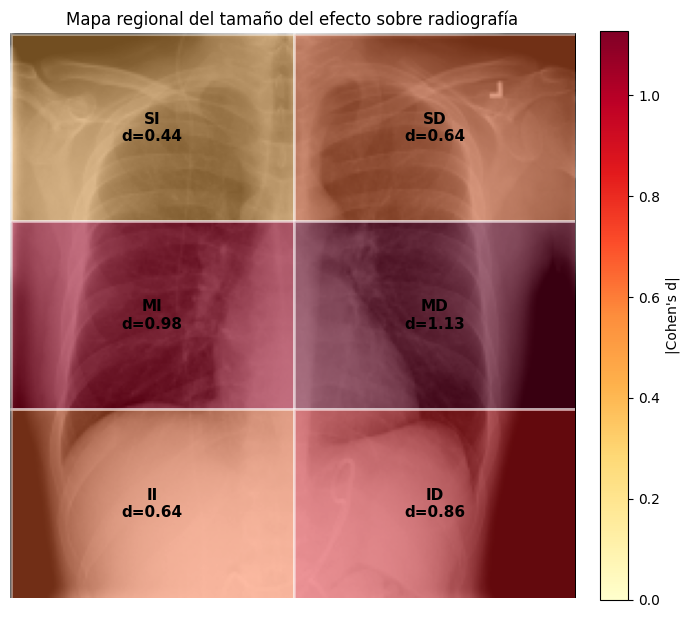

In [ ]:
img = cv2.imread(df["path"].iloc[0], cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (256, 256))

valores = {
    "SI": 0.438424,
    "SD": 0.638312,
    "MI": 0.981532,
    "MD": 1.127402,
    "II": 0.643682,
    "ID": 0.864682
}

regiones = {
    "SI": (0, 0, 128, 85),
    "SD": (128, 0, 128, 85),
    "MI": (0, 85, 128, 85),
    "MD": (128, 85, 128, 85),
    "II": (0, 170, 128, 86),
    "ID": (128, 170, 128, 86)
}

norm = colors.Normalize(vmin=0, vmax=max(valores.values()))
cmap = cm.get_cmap("YlOrRd")

fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(img, cmap="gray")

for region, (x, y, w, h) in regiones.items():
    valor = valores[region]
    color = cmap(norm(valor))

    rect = patches.Rectangle(
        (x, y),
        w,
        h,
        linewidth=2,
        edgecolor="white",
        facecolor=color,
        alpha=0.45
    )

    ax.add_patch(rect)

    ax.text(
        x + w/2,
        y + h/2,
        f"{region}\nd={valor:.2f}",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="black"
    )

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("|Cohen's d|")

ax.set_title("Mapa regional del tamaño del efecto sobre radiografía")
ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
features_cols = [
    c for c in regional_df.columns
    if c not in ["Nombre_Archivo", "clase"]
]

X = regional_df[features_cols]

y = regional_df["clase"]

A continuación se tratara de disminuir el número de características mediante estrategias no supervizadas como PCA y UMAP. El objetivo es ver si algunas de estas priyecciones permiten discriminar las clases o establecer calidad de las imagenes para aplicar AI

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(
    "Varianza explicada:",
    pca.explained_variance_ratio_
)

print(
    "Varianza acumulada:",
    pca.explained_variance_ratio_.sum()
)

Varianza explicada: [0.34358666 0.20195767]
Varianza acumulada: 0.5455443257121763


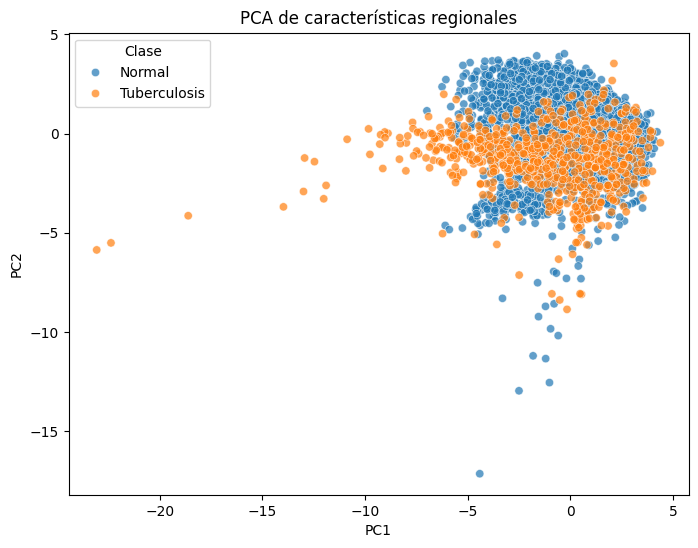

In [ ]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Clase": y
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Clase",
    alpha=0.7
)

plt.title("PCA de características regionales")
plt.show()

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1","PC2"],
    index=features_cols
)

loadings

,PC1,PC2
SI_mean,-0.198475,0.268086
SI_std,0.185091,0.232066
SI_entropy,0.121744,0.339330
SD_mean,-0.228473,0.257742
SD_std,0.205955,0.231068
SD_entropy,0.180187,0.308104
MI_mean,-0.239972,0.319318
MI_std,0.278747,0.078429
MI_entropy,0.297443,0.194524
MD_mean,-0.250063,0.315776


In [ ]:
loadings["PC1_abs"] = np.abs(loadings["PC1"])

loadings.sort_values(
    "PC1_abs",
    ascending=False
).head(10)

,PC1,PC2,PC1_abs
MD_entropy,0.314092,0.151856,0.314092
MI_entropy,0.297443,0.194524,0.297443
ID_std,0.297122,-0.030860,0.297122
MD_std,0.293624,0.064647,0.293624
II_std,0.293480,-0.030561,0.293480
MI_std,0.278747,0.078429,0.278747
MD_mean,-0.250063,0.315776,0.250063
MI_mean,-0.239972,0.319318,0.239972
SD_mean,-0.228473,0.257742,0.228473
ID_entropy,0.221914,0.138589,0.221914


In [ ]:
!pip install umap-learn

In [ ]:
import umap.umap_ as umap

In [ ]:
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


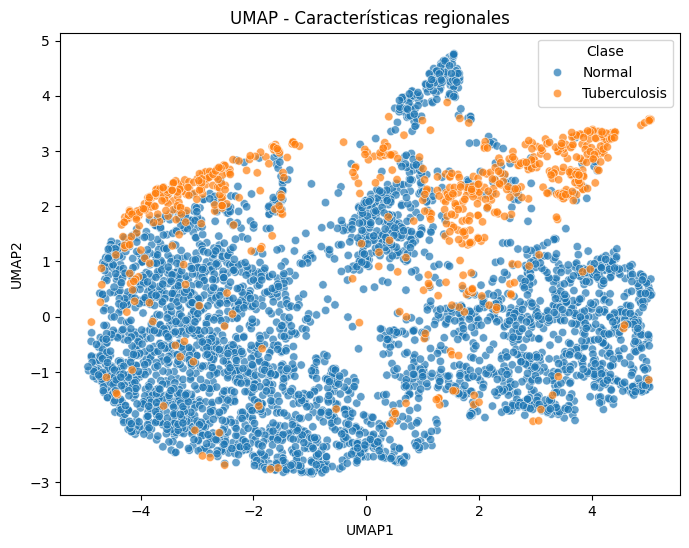

In [ ]:
umap_df = pd.DataFrame({
    "UMAP1": X_umap[:,0],
    "UMAP2": X_umap[:,1],
    "Clase": y
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="Clase",
    alpha=0.7
)

plt.title("UMAP - Características regionales")
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
silhouette_scores = []

K = range(2,11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

    print(f"k={k} -> silhouette={score:.4f}")

k=2 -> silhouette=0.2636
k=3 -> silhouette=0.2337
k=4 -> silhouette=0.2410
k=5 -> silhouette=0.1946
k=6 -> silhouette=0.1975
k=7 -> silhouette=0.1572
k=8 -> silhouette=0.1706
k=9 -> silhouette=0.1602
k=10 -> silhouette=0.1575


In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled)

regional_df["Cluster"] = clusters
umap_df["Cluster"] = clusters

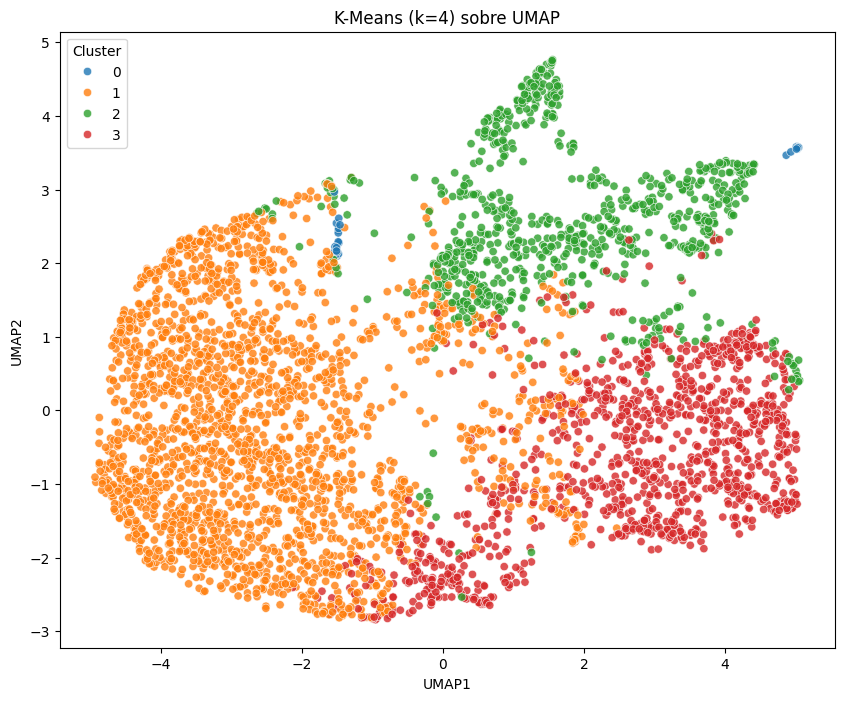

In [ ]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="Cluster",
    palette="tab10",
    alpha=0.8
)

plt.title("K-Means (k=4) sobre UMAP")
plt.show()

In [ ]:
pd.crosstab(
    regional_df["Cluster"],
    regional_df["clase"]
)

clase,Normal,Tuberculosis
Cluster,,
0,16,19
1,1929,280
2,480,356
3,1075,45


In [ ]:
pd.crosstab(
    regional_df["Cluster"],
    regional_df["clase"],
    normalize="index"
)*100

clase,Normal,Tuberculosis
Cluster,,
0,45.714286,54.285714
1,87.324581,12.675419
2,57.416268,42.583732
3,95.982143,4.017857


In [ ]:
perfil = regional_df.groupby(
    "Cluster"
).mean(
    numeric_only=True
)

perfil.T

Cluster,0,1,2,3
SI_mean,67.655515,93.174234,109.996263,129.559355
SI_std,48.387269,54.198208,39.722730,52.720418
SI_entropy,3.326868,4.937107,4.600905,4.952427
SD_mean,115.073537,93.857000,112.040390,129.948312
SD_std,49.835329,54.095272,38.302461,52.743973
SD_entropy,2.067048,4.963904,4.607110,4.975286
MI_mean,124.433973,109.163058,121.853679,151.944101
MI_std,61.283591,52.098585,32.905509,44.276144
MI_entropy,4.269570,5.059695,4.582212,4.895293
MD_mean,163.909879,115.611362,127.771916,157.693113


In [ ]:
regional_df = regional_df.merge(
    df[["Nombre_Archivo", "path"]],
    on="Nombre_Archivo",
    how="left"
)

In [ ]:
regional_df.head()

,Nombre_Archivo,clase,SI_mean,SI_std,SI_entropy,SD_mean,SD_std,SD_entropy,MI_mean,MI_std,...,MD_std,MD_entropy,II_mean,II_std,II_entropy,ID_mean,ID_std,ID_entropy,Cluster,path
0,Normal-859.png,Normal,95.624632,46.973531,5.096575,84.558456,40.805147,4.969596,96.259191,47.999651,...,51.273506,4.921625,153.183957,77.139011,4.963658,115.212118,86.803641,4.488998,1,/kaggle/input/tuberculosis-tb-chest-xray-datas...
1,Normal-158.png,Normal,90.407629,42.056373,4.568090,85.861581,43.641310,4.562295,111.423897,32.040506,...,38.046296,4.587980,109.732649,53.407716,4.286876,97.115280,56.197432,4.281219,2,/kaggle/input/tuberculosis-tb-chest-xray-datas...
2,Normal-1811.png,Normal,142.015074,69.620219,4.877868,150.404504,52.438641,4.922106,151.211581,55.681317,...,33.681604,4.643379,160.347929,82.958252,4.651614,181.101017,51.177062,4.902532,3,/kaggle/input/tuberculosis-tb-chest-xray-datas...
3,Normal-97.png,Normal,97.894669,59.810197,4.953109,114.605423,55.887496,5.171929,93.238695,48.140537,...,55.142654,5.123088,103.210938,80.592912,4.952549,143.436682,71.762702,5.276061,1,/kaggle/input/tuberculosis-tb-chest-xray-datas...
4,Normal-1088.png,Normal,77.330147,47.687031,5.002809,74.089062,48.841775,4.941105,149.940441,48.453375,...,51.186735,5.135364,198.487373,47.283300,4.460717,145.538790,89.051038,4.641360,1,/kaggle/input/tuberculosis-tb-chest-xray-datas...


In [ ]:
cluster0 = regional_df[
    regional_df["Cluster"] == 0
]

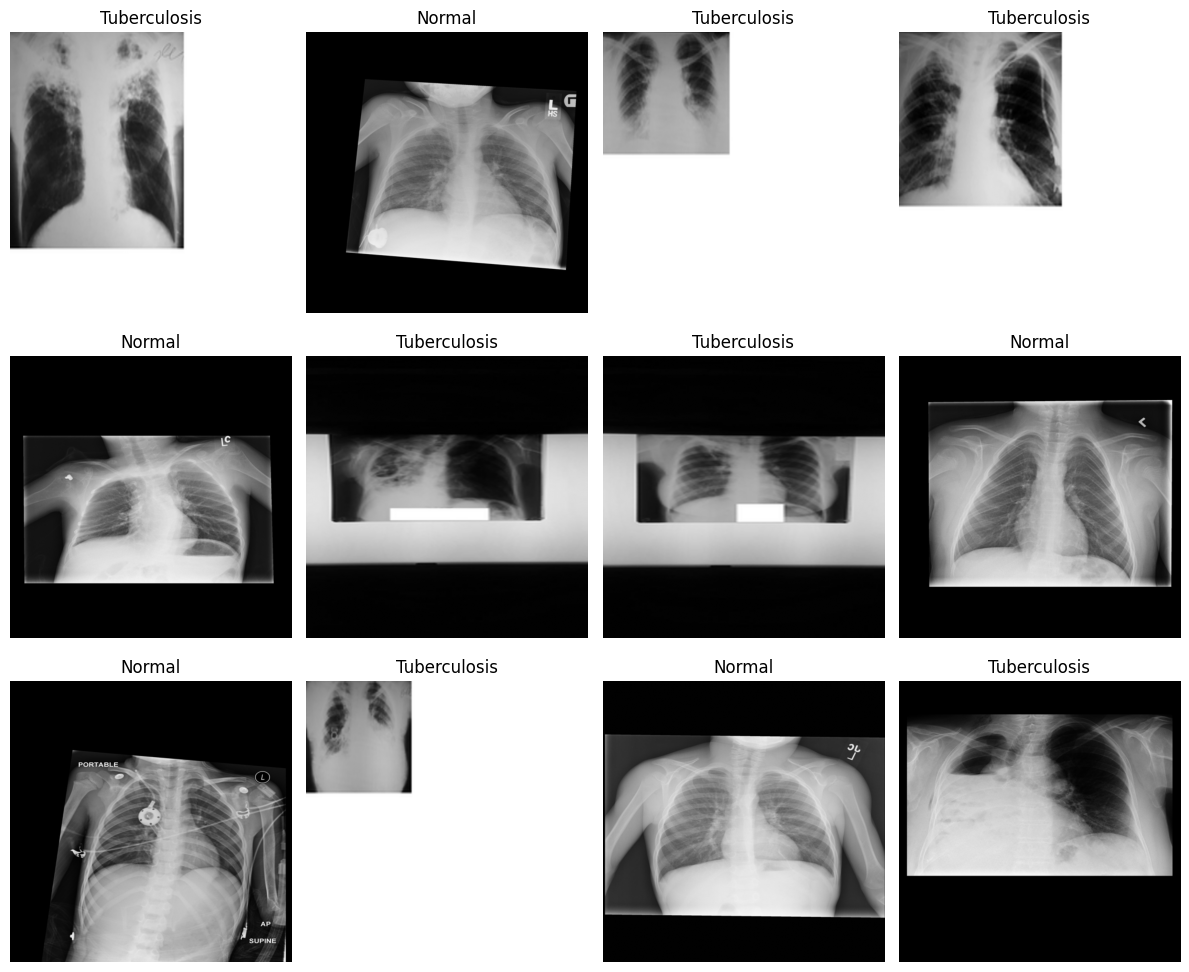

In [ ]:
sample = cluster0.sample(
    min(12, len(cluster0)),
    random_state=42
)

fig, axes = plt.subplots(3,4, figsize=(12,10))

for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):

    img = cv2.imread(
        row["path"],
        cv2.IMREAD_GRAYSCALE
    )

    ax.imshow(img, cmap="gray")
    ax.set_title(row["clase"])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
35 / len(regional_df) * 100

0.8333333333333334

In [ ]:
regional_clean = regional_df[
    regional_df["Cluster"] != 0
].copy()

print("Imágenes originales:", len(regional_df))
print("Imágenes depuradas:", len(regional_clean))
print("Imágenes eliminadas:", len(regional_df) - len(regional_clean))

Imágenes originales: 4200
Imágenes depuradas: 4165
Imágenes eliminadas: 35


In [ ]:
features_cols = [
    c for c in regional_clean.columns
    if c not in [
        "Nombre_Archivo",
        "clase",
        "Cluster",
        "path"
    ]
]

X_clean = regional_clean[features_cols]

y_clean = regional_clean["clase"]

In [ ]:
scaler = StandardScaler()
X_scaled_clean = scaler.fit_transform(X_clean)

In [ ]:
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    random_state=42
)

X_umap_clean = reducer.fit_transform(X_scaled_clean)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


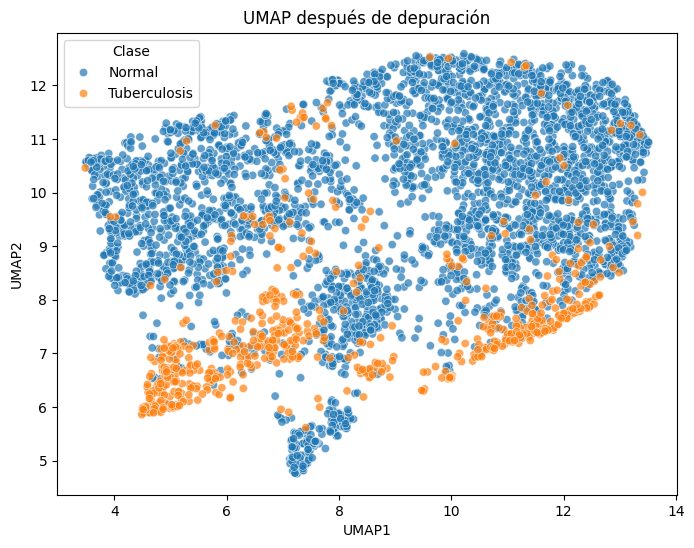

In [ ]:
umap_df_clean = pd.DataFrame({
    "UMAP1": X_umap_clean[:,0],
    "UMAP2": X_umap_clean[:,1],
    "Clase": y_clean.values
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=umap_df_clean,
    x="UMAP1",
    y="UMAP2",
    hue="Clase",
    alpha=0.7
)

plt.title("UMAP después de depuración")
plt.show()

In [ ]:
scores = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_scaled_clean)

    score = silhouette_score(
        X_scaled_clean,
        labels
    )

    scores.append(score)

    print(f"k={k} -> silhouette={score:.4f}")

k=2 -> silhouette=0.2630
k=3 -> silhouette=0.2364
k=4 -> silhouette=0.2039
k=5 -> silhouette=0.1557
k=6 -> silhouette=0.1705
k=7 -> silhouette=0.1465
k=8 -> silhouette=0.1643
k=9 -> silhouette=0.1504
k=10 -> silhouette=0.1449


In [ ]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled_clean)

regional_clean["Cluster"] = clusters
umap_df_clean["Cluster"] = clusters

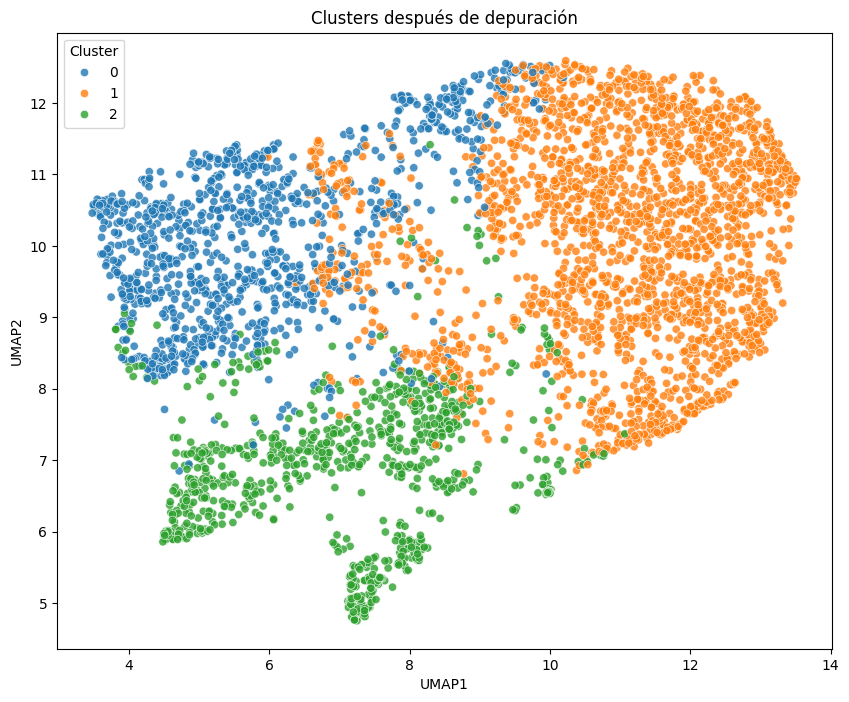

In [ ]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=umap_df_clean,
    x="UMAP1",
    y="UMAP2",
    hue="Cluster",
    palette="tab10",
    alpha=0.8
)

plt.title("Clusters después de depuración")

plt.show()

In [ ]:
(
    pd.crosstab(
        regional_clean["Cluster"],
        regional_clean["clase"],
        normalize="index"
    ) * 100
).round(2)

clase,Normal,Tuberculosis
Cluster,,
0,95.85,4.15
1,88.21,11.79
2,56.62,43.38


In [ ]:
perfil = regional_clean.groupby(
    "Cluster"
).mean(
    numeric_only=True
).round(3)

perfil.T

Cluster,0,1,2
SI_mean,130.068,93.593,108.157
SI_std,52.516,54.220,40.458
SI_entropy,4.951,4.952,4.578
SD_mean,130.392,94.336,110.076
SD_std,52.624,54.076,39.084
SD_entropy,4.974,4.979,4.585
MI_mean,152.146,109.564,120.695
MI_std,44.126,52.143,33.607
MI_entropy,4.894,5.067,4.580
MD_mean,157.786,116.139,126.445


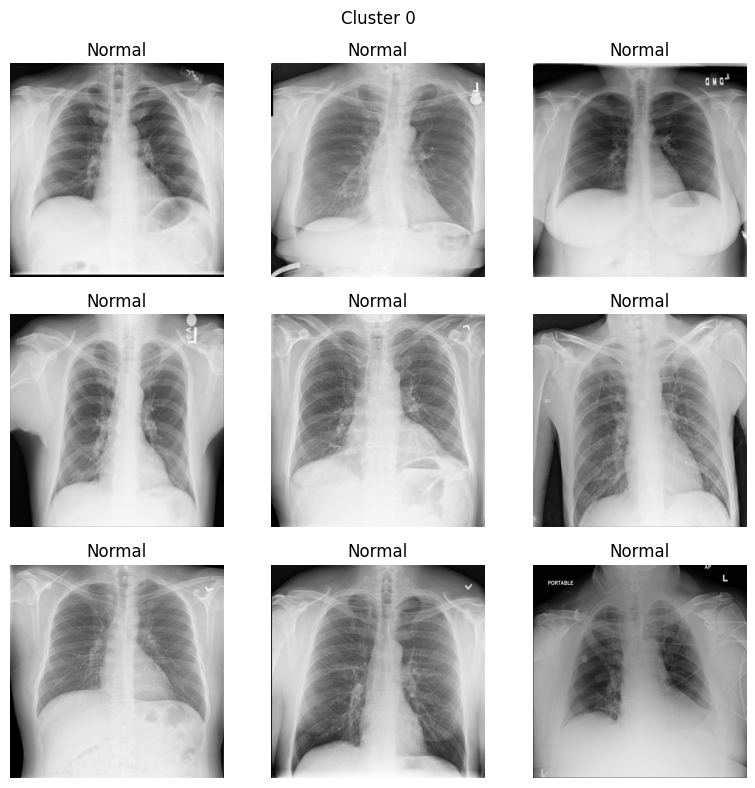

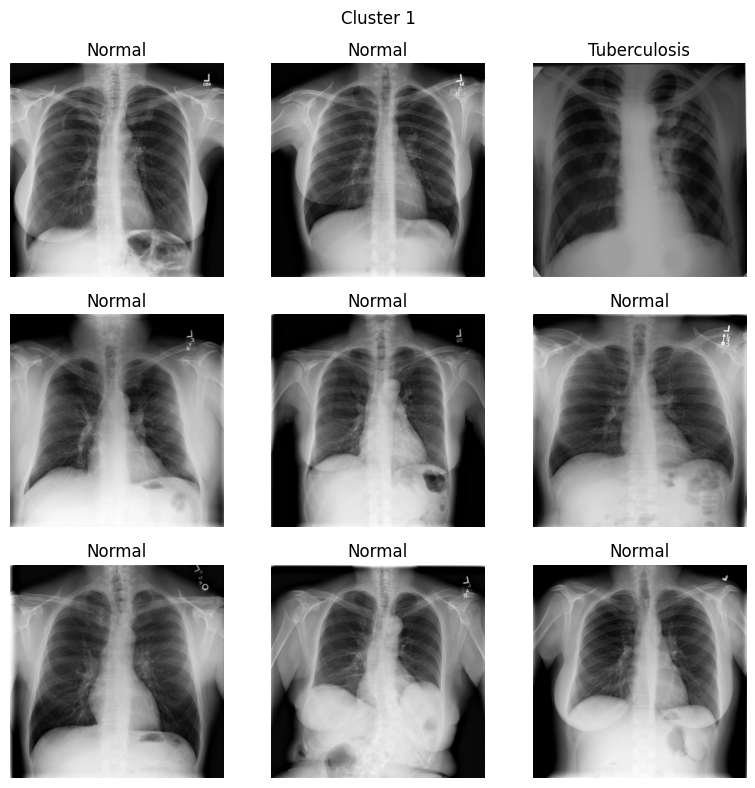

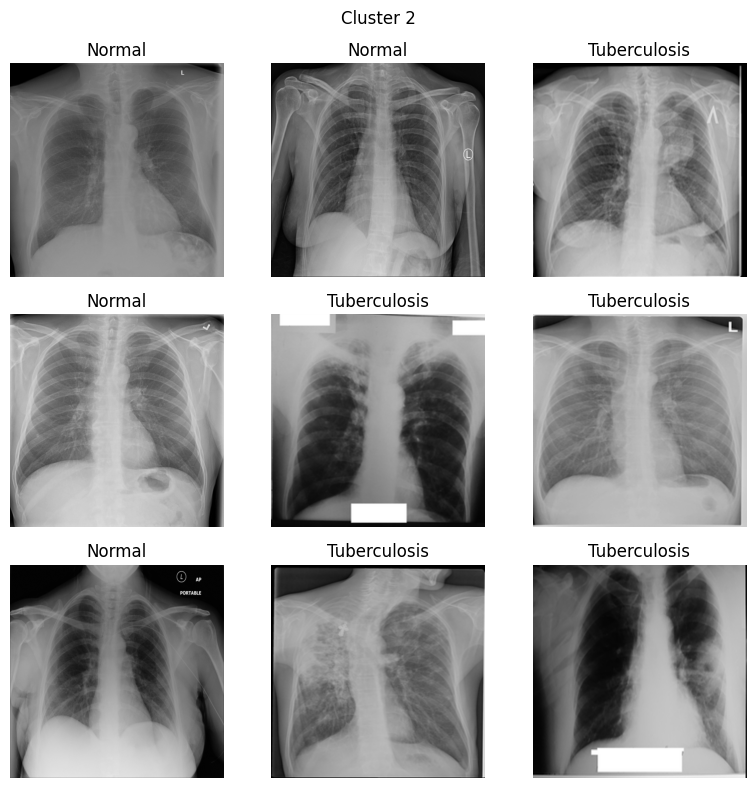

In [ ]:
for c in [0,1,2]:

    muestra = regional_clean[
        regional_clean["Cluster"] == c
    ].sample(
        min(9,
            len(regional_clean[
                regional_clean["Cluster"] == c
            ])
        ),
        random_state=42
    )

    fig, axes = plt.subplots(
        3,3,
        figsize=(8,8)
    )

    for ax, (_, row) in zip(
        axes.flatten(),
        muestra.iterrows()
    ):

        img = cv2.imread(
            row["path"],
            cv2.IMREAD_GRAYSCALE
        )

        ax.imshow(
            img,
            cmap="gray"
        )

        ax.set_title(
            row["clase"]
        )

        ax.axis("off")

    plt.suptitle(
        f"Cluster {c}"
    )

    plt.tight_layout()

    plt.show()

In [ ]:
quality_features = []

for _, row in df.iterrows():

    img = cv2.imread(row["path"], cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    img = cv2.resize(img, (256, 256))

    # Porcentaje de fondo negro o casi negro
    black_ratio = np.mean(img < 10)

    # Contraste
    contrast = np.std(img)

    # Entropía
    hist = cv2.calcHist([img], [0], None, [256], [0, 256]).flatten()
    hist_prob = hist / hist.sum()
    img_entropy = entropy(hist_prob + 1e-10)

    # Nitidez / enfoque usando varianza del Laplaciano
    sharpness = cv2.Laplacian(img, cv2.CV_64F).var()

    quality_features.append({
        "Nombre_Archivo": row["Nombre_Archivo"],
        "path": row["path"],
        "clase": row["clase"],
        "black_ratio": black_ratio,
        "contrast": contrast,
        "entropy": img_entropy,
        "sharpness": sharpness
    })

quality_df = pd.DataFrame(quality_features)
quality_df.head()

,Nombre_Archivo,path,clase,black_ratio,contrast,entropy,sharpness
0,Normal-859.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,0.102402,65.532011,5.209355,114.067668
1,Normal-158.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,0.072815,46.008638,4.686333,74.276893
2,Normal-1811.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,0.043167,61.310055,5.043194,197.711916
3,Normal-97.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,0.090302,65.053755,5.288671,131.353046
4,Normal-1088.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,0.080658,71.969291,5.345091,127.644737


In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
X_quality = quality_df[
    ["black_ratio","contrast","entropy","sharpness"]
]

iso = IsolationForest(
    contamination=0.01,
    random_state=42
)

quality_df["outlier"] = iso.fit_predict(X_quality)

In [ ]:
quality_df["outlier"].value_counts()

,count
outlier,
1,4158
-1,42


In [ ]:
outliers = quality_df[
    quality_df["outlier"] == -1
]["Nombre_Archivo"]

cluster0 = regional_df[
    regional_df["Cluster"] == 0
]["Nombre_Archivo"]

interseccion = set(outliers).intersection(set(cluster0))

print("Coincidencias:", len(interseccion))

Coincidencias: 33
